# 대여소별 수요 회귀 모델

- `data/서울특별시_공공자전거_이용정보_시간대별__202606.csv` — 2026년 6월, 대여소 2,761개 시간대별 실제 이용 로그
- `data/공공자전거_대여소_정보_26_6월_기준_.xlsx` — 대여소 번호별 위치/거치대 수 (대여소 번호로만 조인해서 피처 추가)

이 노트북은 "이 대여소가, 이 시간대에, 평소 몇 건 정도 대여되는지"를 예측하는 모델 생성

#### 1. 라이브러리 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

pd.set_option('display.max_columns', None)

#### 2. 데이터 불러오기 대여소별 이용 시간대별

In [2]:
usage = pd.read_csv(
    '../data/서울특별시 공공자전거 이용정보(시간대별)_202606.csv',
    encoding='cp949'
)
usage.head()

,대여일자,대여시간,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2026-06-01,0,1028,1028. 포레스 주상복합 빌딩,정기권,NaN,20대,1,19.81,0.18,769.67,4
1,2026-06-01,0,1150,1150. 송정역 1번출구,정기권,NaN,20대,1,39.88,0.36,1549.49,9
2,2026-06-01,0,1535,1535. 효성인텔리안 앞,정기권,NaN,20대,1,22.14,0.20,860.08,6
3,2026-06-01,0,1650,1650. 중계근린공원내,정기권,NaN,20대,1,13.12,0.12,509.69,6
4,2026-06-01,0,2271,2271. 내방역 8번출구 앞,정기권,NaN,20대,1,23.97,0.22,931.08,8


In [3]:
print('행/열:', usage.shape)
usage.info()

행/열: (3660184, 12)
<class 'pandas.DataFrame'>
RangeIndex: 3660184 entries, 0 to 3660183
Data columns (total 12 columns):
 #   Column   Dtype  
---  ------   -----  
 0   대여일자     str    
 1   대여시간     int64  
 2   대여소번호    int64  
 3   대여소명     str    
 4   대여구분코드   str    
 5   성별       str    
 6   연령대코드    str    
 7   이용건수     int64  
 8   운동량      str    
 9   탄소량      str    
 10  이동거리(M)  float64
 11  이용시간(분)  int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 335.1 MB


#### 3. 데이터 불러오기 - 대여소

In [4]:
# 원본 엑셀의 '진짜' 컬럼을 먼저 있는 그대로 확인 (추측/가정 없이)
# header=3 위의 실제 헤더 행에 위도/경도, 동 단위 주소가 별도 컬럼으로 있는지 여기서 직접 확인합니다.
raw_station = pd.read_excel('../data/공공자전거 대여소 정보(26.6월 기준).xlsx', header=3)
print('원본 컬럼 목록:', list(raw_station.columns))
raw_station.head(10)

원본 컬럼 목록: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', '거치\n대수', '거치\n대수.1', 'Unnamed: 9']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,거치\n대수,거치\n대수.1,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102.0,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,NaN,15.0,QR
2,103.0,망원역 2번출구 앞,마포구,서울특별시 마포구 월드컵로 79,37.554951,126.910835,2015-09-06 23:43:13,NaN,14.0,QR
3,104.0,합정역 1번출구 앞,마포구,서울특별시 마포구 양화로 59,37.550629,126.914986,2015-09-06 23:44:31,NaN,13.0,QR
4,105.0,합정역 5번출구 앞,마포구,서울특별시 마포구 양화로 48,37.550007,126.914825,2015-09-06 23:45:30,NaN,5.0,QR
5,106.0,합정역 7번출구 앞,마포구,서울특별시 마포구 독막로 4,37.548645,126.912827,2015-09-06 23:46:31,NaN,12.0,QR
6,107.0,신한은행 서교동지점,마포구,서울특별시 마포구 월드컵북로 35,37.557510,126.918503,2015-09-06 23:47:57,NaN,5.0,QR
7,108.0,서교동 사거리,마포구,서울특별시 마포구 양화로 93,37.552746,126.918617,2015-09-06 23:51:25,NaN,10.0,QR
8,111.0,상수역 2번출구 앞,마포구,서울특별시 마포구 와우산로 40,37.547871,126.923531,2015-09-07 01:30:37,NaN,10.0,QR
9,113.0,홍대입구역 2번출구 앞,마포구,서울특별시 마포구 양화로 165,37.557438,126.923821,2015-09-07 01:32:58,NaN,25.0,QR


In [5]:
# ↑ 출력된 원본 컬럼명을 그대로 써서 매핑합니다 (임의로 만들지 않고, 실제 존재하는 컬럼만 이름만 정리).
# 주의: 아래 컬럼 개수/순서는 위 출력 결과를 보고 실제 컬럼 수에 맞게 반드시 조정해야 합니다.
# (이전 버전은 이 시점에서 addr1/addr2/addr3, 위도/경도 컬럼을 통째로 버리고 있었습니다 -> 그래서 '동'과
#  좌표가 결과물에 없었고, 이후 다른 곳에서 임의로 채워 넣게 된 것입니다.)
station = raw_station.copy()
station.columns = ['station_id','station_name','district','addr1','addr2','addr3',
                    'install_date','install_type','rack_count','operation_type']
station = station.dropna(subset=['station_id'])
station['station_id'] = station['station_id'].astype(int)

# 주소 원문 샘플을 직접 눈으로 확인 (동 이름이 어느 컬럼/어느 위치에 있는지 정제 전에 검증)
station[['station_id','station_name','district','addr1','addr2','addr3']].sample(15, random_state=1)

,station_id,station_name,district,addr1,addr2,addr3
232,394,경희궁 자이 3단지,종로구,서울특별시 종로구 경교장길 35 경희궁자이 3단지,37.567490,126.965919
1883,3586,군자역 비채온 오피스텔,광진구,서울특별시 광진구 군자동 473-26,37.557713,127.077271
956,1418,새솔초등학교,중랑구,서울특별시 중랑구 신내역로1길 164 새솔초등학교,37.617439,127.109016
686,1037,강일리버파크 6단지,강동구,서울특별시 강일동 448-2,37.562565,127.177612
1021,1525,미아동 복합청사,강북구,서울특별시 강북구 솔매로49길 14 미아동 195-1,37.627140,127.026695
1551,2396,영동3교 북단(우성캐릭터 앞 보도),강남구,강남구 도곡동 466,37.485741,127.051048
969,1435,능산삼거리,중랑구,서울특별시 중랑구 용마산로 644 능산삼거리,37.608681,127.100792
1711,2809,항동지구 11단지 1103동 앞,구로구,구로구 항동 169-1,37.477905,126.823112
2388,4573,두산위브아파트,영등포구,영등포구 신길로60나길 9,37.514702,126.912140
2550,4873,개롱역사거리 2번 출구,송파구,송파구 오금동 166,37.498272,127.134865


#### 6-1. '동' 추출 (외부 API/임의 CSV 없이, 원본 주소 컬럼에서 직접 파싱)

In [6]:
import re

def extract_dong(*addr_parts):
    """주소 문자열들에서 법정동/행정동 이름을 정규식으로 추출합니다.
    예: '서울특별시 강동구 암사동 123-4' -> '암사동'
    ※ 위 셀에서 addr1/addr2/addr3 샘플을 직접 확인한 뒤,
      실제 동 이름이 들어있는 패턴에 맞게 정규식을 조정하세요.
    """
    text = ' '.join(str(p) for p in addr_parts if pd.notna(p))
    # '~동' 또는 '~1동' 형태의 토큰을 찾되, 흔한 오탐(운동, 자동 등)은 제외
    match = re.search(r'([가-힣]{1,6}\d?동)(?=\s|$)', text)
    return match.group(1) if match else None

station['dong'] = station.apply(
    lambda r: extract_dong(r['addr1'], r['addr2'], r['addr3']), axis=1
)

print('동 추출 성공률:', station['dong'].notna().mean().__round__(3))
station[station['dong'].isna()][['station_id','station_name','addr1','addr2','addr3']].head(10)

동 추출 성공률: 0.347


,station_id,station_name,addr1,addr2,addr3
1,102,망원역 1번출구 앞,서울특별시 마포구 월드컵로 72,37.555649,126.910629
2,103,망원역 2번출구 앞,서울특별시 마포구 월드컵로 79,37.554951,126.910835
3,104,합정역 1번출구 앞,서울특별시 마포구 양화로 59,37.550629,126.914986
4,105,합정역 5번출구 앞,서울특별시 마포구 양화로 48,37.550007,126.914825
5,106,합정역 7번출구 앞,서울특별시 마포구 독막로 4,37.548645,126.912827
6,107,신한은행 서교동지점,서울특별시 마포구 월드컵북로 35,37.557510,126.918503
7,108,서교동 사거리,서울특별시 마포구 양화로 93,37.552746,126.918617
8,111,상수역 2번출구 앞,서울특별시 마포구 와우산로 40,37.547871,126.923531
9,113,홍대입구역 2번출구 앞,서울특별시 마포구 양화로 165,37.557438,126.923821
10,114,홍대입구역 8번출구 앞,서울특별시 마포구 양화로18길 3,37.557060,126.924423


**검증 필요**: 위 두 셀의 출력(원본 컬럼 목록 + 샘플 주소)을 직접 보고,
1. `addr1/addr2/addr3` 중 실제로 동 이름이 들어있는 컬럼이 맞는지
2. 정규식이 실제 패턴과 맞는지 (안 맞으면 추출 실패율이 높게 나옵니다)
를 확인한 뒤 다음 단계로 진행합니다. 이 노트북을 실행한 결과(성공률, 실패 샘플)를 그대로 다음 대화에 공유해주시면
그 결과를 보고 정규식을 다시 맞춰드릴게요.

#### 4. EDA

In [7]:
usage.isnull().sum()

대여일자            0
대여시간            0
대여소번호           0
대여소명            0
대여구분코드          0
성별         921868
연령대코드           0
이용건수            0
운동량             0
탄소량             0
이동거리(M)         0
이용시간(분)         0
dtype: int64

/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/

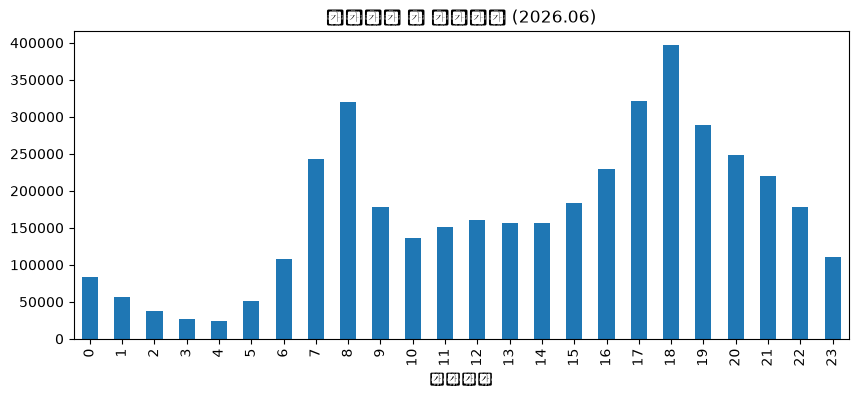

In [8]:
# 시간대별 총 이용건수
hourly = usage.groupby('대여시간')['이용건수'].sum()
plt.figure(figsize=(10,4))
hourly.plot(kind='bar')
plt.title('시간대별 총 이용건수 (2026.06)')
plt.show()

In [9]:
station['rack_count'].describe()

count    1740.000000
mean       11.866667
std         6.058516
min         2.000000
25%         9.000000
50%        10.000000
75%        14.000000
max        62.000000
Name: rack_count, dtype: float64

#### 5. 전처리: 날짜+시간+대여소로 이용건수 합산

In [10]:
# 성별/연령대/대여구분 등으로 잘게 나뉜 로그를 (날짜, 시간, 대여소) 단위로 합산
agg = usage.groupby(['대여일자','대여시간','대여소번호'], as_index=False)['이용건수'].sum()
agg.columns = ['date','hour','station_id','rental_count']
agg.head()

,date,hour,station_id,rental_count
0,2026-06-01,0,102,6
1,2026-06-01,0,103,6
2,2026-06-01,0,106,5
3,2026-06-01,0,107,4
4,2026-06-01,0,108,1


#### 6. 전처리: '이용 0건'인 시간대도 포함시키기
대여 로그에는 실제로 이용이 있었던 (날짜, 시간, 대여소) 조합만 있고, 이용이 0건인 조합은 아예 행이 없어요.
이걸 그대로 학습하면 모델이 '0건'인 경우를 한 번도 못 보고 항상 과대예측하게 되니, 전체 조합 그리드를 만들어서 없는 조합은 0으로 채웁니다.

In [11]:
stations = agg['station_id'].unique()
dates = pd.date_range('2026-06-01', '2026-06-30').strftime('%Y-%m-%d')
hours = range(24)

grid = pd.MultiIndex.from_product([stations, dates, hours],
                                    names=['station_id','date','hour']).to_frame(index=False)
full = grid.merge(agg, on=['station_id','date','hour'], how='left')
full['rental_count'] = full['rental_count'].fillna(0).astype(int)
print(full.shape)
full.head()

(1987920, 4)


,station_id,date,hour,rental_count
0,102,2026-06-01,0,6
1,102,2026-06-01,1,3
2,102,2026-06-01,2,1
3,102,2026-06-01,3,2
4,102,2026-06-01,4,3


#### 7. 대여소 마스터와 조인 (거치대 수, 지역구 피처 추가)

In [12]:
full = full.merge(station, on='station_id', how='left')
full['rack_count'] = full['rack_count'].fillna(full['rack_count'].median())
full['district'] = full['district'].fillna('알수없음')
full['dong'] = full['dong'].fillna('알수없음')

full['date'] = pd.to_datetime(full['date'])
full['day_of_week'] = full['date'].dt.dayofweek
full['is_weekend'] = (full['day_of_week'] >= 5).astype(int)
full.head()

,station_id,date,hour,rental_count,station_name,district,addr1,addr2,addr3,install_date,install_type,rack_count,operation_type,dong,day_of_week,is_weekend
0,102,2026-06-01,0,6,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,NaN,15.0,QR,알수없음,0,0
1,102,2026-06-01,1,3,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,NaN,15.0,QR,알수없음,0,0
2,102,2026-06-01,2,1,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,NaN,15.0,QR,알수없음,0,0
3,102,2026-06-01,3,2,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,NaN,15.0,QR,알수없음,0,0
4,102,2026-06-01,4,3,망원역 1번출구 앞,마포구,서울특별시 마포구 월드컵로 72,37.555649,126.910629,2015-09-06 23:42:06,NaN,15.0,QR,알수없음,0,0


#### 8. 범주형 인코딩

In [13]:
le = LabelEncoder()
full['district_enc'] = le.fit_transform(full['district'])

#### 9. 학습/검증 데이터 분리

In [14]:
features = ['station_id','hour','day_of_week','is_weekend','rack_count','district_enc']
X = full[features]
y = full['rental_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1590336, 6) (397584, 6)


#### 10. RandomForest 회귀 모델 학습

In [15]:
model = RandomForestRegressor(
    n_estimators=60, max_depth=14, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",60
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

#### 11. 모델 평가

In [16]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f'MAE: {mae:.3f}')
print(f'R2 Score: {r2:.4f}')

# 참고: 대여소·시간 단위 이용건수는 중앙값이 1건일 정도로 변동성이 커서
# R2가 낮게 나오는 게 정상입니다 (날씨 데이터가 없는 상태의 순수 패턴 모델).


MAE: 1.575
R2 Score: 0.4515


/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/dev/smart-bicycle-service/server/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeong-yewon/de

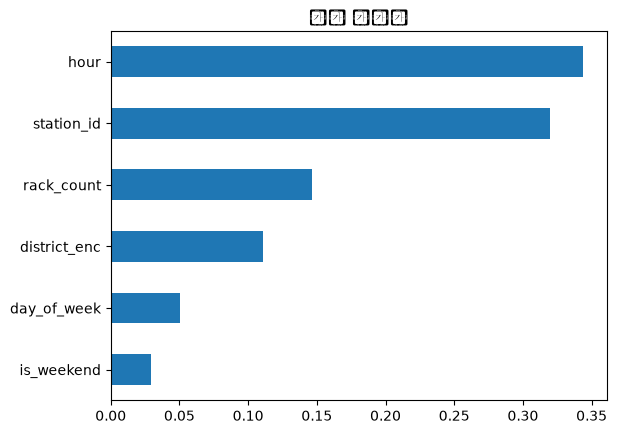

In [17]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind='barh')
plt.title('피처 중요도')
plt.gca().invert_yaxis()
plt.show()

#### 12. 모델 저장

In [18]:
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/station_demand_model.pkl')
joblib.dump(le, '../models/district_encoder.pkl')

# 최종 저장 컬럼: station_id, station_name, district(구), dong(동), rack_count
# 참고: 이 원본 엑셀(header=3 기준)에는 위도/경도 컬럼이 없습니다.
# 대여소 현황 페이지의 '인근 대여소' 기능에 위경도가 필요하다면,
# 원본 엑셀에 위도/경도 컬럼이 실제로 존재하는지 위 6번 셀의 원본 컬럼 목록 출력에서 확인하고,
# 있다면 여기서 함께 저장해야 합니다. (임의로 좌표를 만들어 넣지 않습니다.)
station_master = station[['station_id', 'station_name', 'district', 'dong', 'rack_count']].drop_duplicates(subset='station_id')
station_master.to_csv('../models/station_master.csv', index=False)
print('저장 완료')
station_master.sample(10, random_state=1)

저장 완료


,station_id,station_name,district,dong,rack_count
232,394,경희궁 자이 3단지,종로구,NaN,15.0
1883,3586,군자역 비채온 오피스텔,광진구,군자동,8.0
956,1418,새솔초등학교,중랑구,NaN,NaN
686,1037,강일리버파크 6단지,강동구,강일동,NaN
1021,1525,미아동 복합청사,강북구,미아동,NaN
1551,2396,영동3교 북단(우성캐릭터 앞 보도),강남구,도곡동,NaN
969,1435,능산삼거리,중랑구,NaN,NaN
1711,2809,항동지구 11단지 1103동 앞,구로구,항동,10.0
2388,4573,두산위브아파트,영등포구,NaN,10.0
2550,4873,개롱역사거리 2번 출구,송파구,오금동,7.0


In [19]:
# station = station[['station_id','district','rack_count']].drop_duplicates(subset='station_id')